# Web3 Python 100本ノック：第1章
## §1-7：NFTの「画像データ」の隠し場所（IPFS）を暴け

Q6で、NFTの所有者はスマートコントラクト上の台帳で管理されていることがわかりました。
では、あの有名な「サルの画像」そのものはどこにあるのでしょうか？実は、ブロックチェーン上に高画質な画像データを直接保存すると、莫大なGas代（手数料）がかかってしまうため、画像は**「IPFS」などのブロックチェーン外の分散型ストレージ**に置かれるのが一般的です。

この問題では、コントラクトから画像への「リンクURL」を取得し、NFTの裏側にあるメタデータ（JSON）を暴き出します。

> **注意**: 各セルを順番に実行してください。

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tsukumo-999/web3-knock100-first-half/blob/master/s1-7_nft_ipfs.ipynb)

In [ ]:
#!pip install web3==7.16.0 requests

## 1. `tokenURI` でリンクを取得

ERC721規格には、そのNFTのデータ（メタデータ）がどこにあるかを示す **`tokenURI(tokenId)`** という関数があります。まずはこれを呼び出してみましょう。

In [ ]:
from web3 import Web3

RPC_URL = "https://eth.drpc.org"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
w3 = Web3(Web3.HTTPProvider(RPC_URL, request_kwargs={'headers': headers, 'timeout': 5}))

# BAYCのコントラクトアドレス
BAYC_ADDRESS = w3.to_checksum_address("0xBC4CA0EdA7647A8aB7C2061c2E118A18a936f13D")

# tokenURI だけを定義した最小ABI
erc721_uri_abi = [
    {
        "inputs": [{"internalType": "uint256", "name": "tokenId", "type": "uint256"}],
        "name": "tokenURI",
        "outputs": [{"internalType": "string", "name": "", "type": "string"}],
        "stateMutability": "view",
        "type": "function"
    }
]

bayc_contract = w3.eth.contract(address=BAYC_ADDRESS, abi=erc721_uri_abi)
# idを変えれば別のBAYCのtokenURIも取得できます。
token_id = 1

try:
    # tokenURIを取得
    uri = bayc_contract.functions.tokenURI(token_id).call()
    print(f"BAYC #{token_id} の tokenURI:")
    print(f" {uri}")
except Exception as e:
    print(f" エラー: {e}")

BAYC #1 の tokenURI:
 ipfs://QmeSjSinHpPnmXmspMjwiXyN6zS4E9zccariGR3jxcaWtq/1


実効に成功すると："ipfs://"から始まるURLを取得できます。

## 2. IPFSのデータを取得してJSONを解析する

取得したURIは `ipfs://...` という形式になっています。これは通常のブラウザ（HTTP）では開けないため、**IPFSゲートウェイ**（`https://ipfs.io/ipfs/` など）を経由してアクセスします。

Pythonの `requests` ライブラリを使って、このURLの中身（JSONデータ）を覗いてみましょう。

In [3]:
import requests

print("IPFSからメタデータを取得中...")

# ipfs:// を HTTPゲートウェイのURLに変換
if uri.startswith("ipfs://"):
    # ipfs:// のプレフィックスを取り除き、ゲートウェイURLを結合
    ipfs_hash = uri.replace("ipfs://", "")
    gateway_url = f"https://ipfs.io/ipfs/{ipfs_hash}"
    
    try:
        # Web APIを叩くようにJSONデータを取得
        response = requests.get(gateway_url, timeout=10)
        metadata = response.json()
        
        print("\nメタデータ（JSON）の取得に成功しました！")
        print("-" * 40)
        
        # 画像のURLと、NFTの属性（Attributes）を抽出
        image_url = metadata.get("image")
        attributes = metadata.get("attributes", [])
        
        print(f" 本当の画像リンク: {image_url}")
        print("\n このサルの属性（パーツ）:")
        for attr in attributes:
            print(f" - {attr.get('trait_type')}: {attr.get('value')}")
            
        print("-" * 40)
        print(" 実際の画像を見たい場合は、上の画像リンクの 'ipfs://' を 'https://ipfs.io/ipfs/' に置き換えてブラウザで開いてみてください。")
        print(f"{image_url.replace('ipfs://', 'https://ipfs.io/ipfs/')}")
        
    except Exception as e:
        print(f" データの取得に失敗しました: {e}")
else:
    print("このNFTはIPFSを使用していません。")

IPFSからメタデータを取得中...

メタデータ（JSON）の取得に成功しました！
----------------------------------------
 本当の画像リンク: ipfs://QmPbxeGcXhYQQNgsC6a36dDyYUcHgMLnGKnF8pVFmGsvqi

 このサルの属性（パーツ）:
 - Mouth: Grin
 - Clothes: Vietnam Jacket
 - Background: Orange
 - Eyes: Blue Beams
 - Fur: Robot
----------------------------------------
 実際の画像を見たい場合は、上の画像リンクの 'ipfs://' を 'https://ipfs.io/ipfs/' に置き換えてブラウザで開いてみてください。
https://ipfs.io/ipfs/QmPbxeGcXhYQQNgsC6a36dDyYUcHgMLnGKnF8pVFmGsvqi


確認した画像例
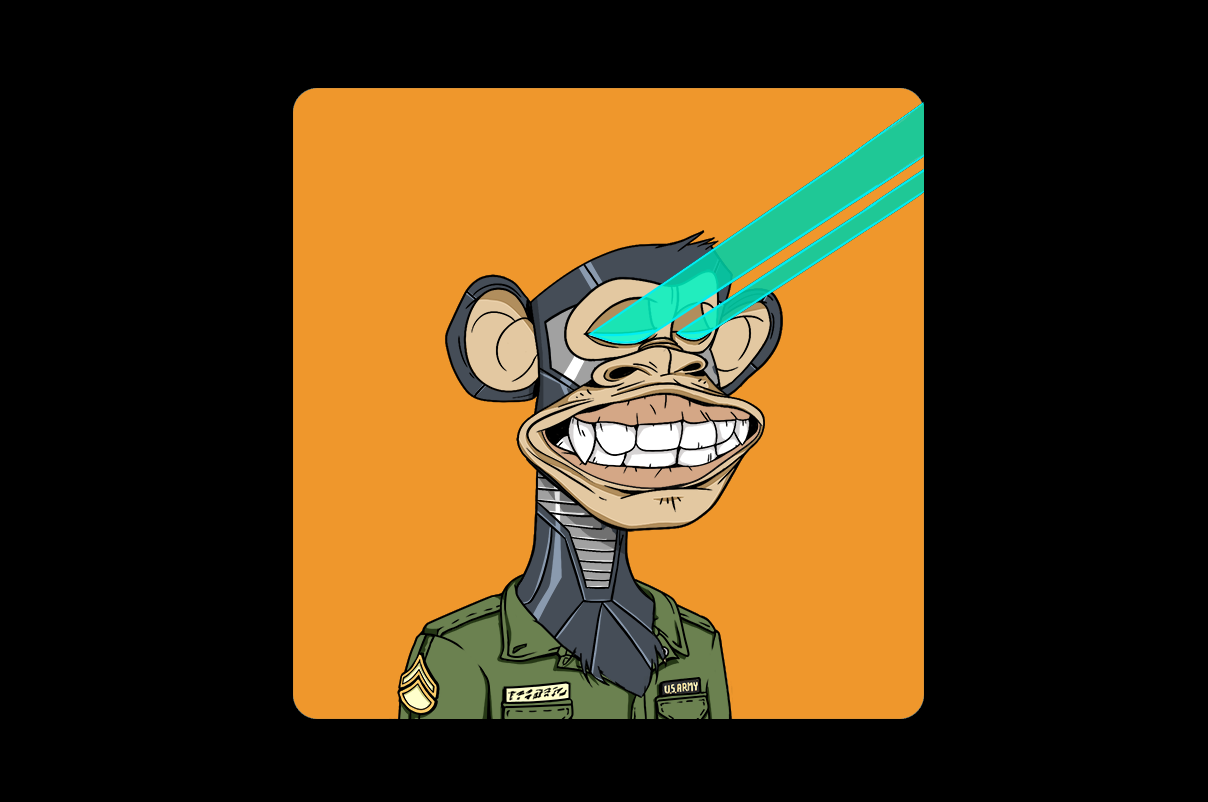